# vit_hope — comparing every model on every object

Aggregates the per-object / per-model result files this project already produces and
answers *which backbone wins, and on which objects?*

**Two sources, deliberately kept apart — their coverage is not the same.**

| Source | Path | Coverage | What it holds |
| --- | --- | --- | --- |
| Pose predictions | `results/remote_predictions/obj_*/predictions_<model>_<tag>.csv` | every object × every trained variant | raw `true_dt_*` / `pred_dt_*` offsets, from which we derive error |
| Image metrics | `results/viz/obj_*/metrics_<model>_<tag>.csv` | **whatever `visualize_all.sh` has finished** — checked at runtime | masked SSIM / MSE / MAE, jittered vs corrected |

`visualize.py` lags inference: predictions come off the cluster, then the renders are
produced locally. So the image grid can be missing object/variant pairs that the pose grid
has — section 3 reports the live state rather than assuming it. Every ranking below states
which source it came from, and the image-metric ranking is always recomputed on the *fair
subset* — the objects where all variants exist — which is a no-op once rendering has
caught up.


## 1 · Setup

In [11]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Notebook lives in vit_hope/ alongside visualize.py.
RESULTS = Path("results")
PRED_DIR = RESULTS / "remote_predictions"
VIZ_DIR = RESULTS / "viz"
assert PRED_DIR.is_dir() and VIZ_DIR.is_dir(), f"run this notebook from vit_hope/ (cwd={Path.cwd()})"

# Same variant vocabulary the producer uses: models.MODEL_SPECS x visualize.TAGS.
TAGS = ("scratch", "frozen", "finetune")
VARIANT_RE = re.compile(rf"^(?:predictions|metrics)_([a-z0-9]+)_({'|'.join(TAGS)})$")


def parse_variant(path):
    """('dinov3', 'frozen') from .../predictions_dinov3_frozen.csv -- mirrors visualize.detect_variant."""
    m = VARIANT_RE.fullmatch(Path(path).stem)
    if not m:
        raise ValueError(f"unrecognised variant filename: {path}")
    return m.group(1), m.group(2)


def parse_obj_id(path):
    """6 from .../obj_000006/whatever.csv -- inverse of Config.obj_stem."""
    stem = Path(path).parent.name
    m = re.fullmatch(r"obj_(\d{6})", stem)
    if not m:
        raise ValueError(f"unrecognised object directory: {stem}")
    return int(m.group(1))


def load_tagged(paths):
    """Concat CSVs, stamping obj_id / model / tag / variant derived from each path.

    metrics_*.csv already carries model/tag/obj_id columns; those are preserved as
    file_{model,tag,obj_id} so they can be cross-checked against the path. The
    path-derived values are the canonical ones, since they also work for
    predictions_*.csv, which carries no labels at all.
    """
    frames = []
    for p in sorted(paths):
        model, tag = parse_variant(p)
        obj_id = parse_obj_id(p)
        # Some files are written column-aligned with padding (e.g.
        # viz/obj_000003/metrics_dinov3_finetune.csv), so strip headers and string cells.
        df = pd.read_csv(p, skipinitialspace=True)
        df.columns = [c.strip() for c in df.columns]
        for c in df.columns:
            if df[c].dtype == object:
                df[c] = df[c].str.strip()
        df = df.rename(columns={c: f"file_{c}" for c in ("model", "tag", "obj_id")
                                if c in df.columns})
        df["obj_id"], df["model"], df["tag"] = obj_id, model, tag
        df["variant"] = f"{model}_{tag}"
        df["source_file"] = str(p)
        frames.append(df)
    if not frames:
        raise FileNotFoundError("no result CSVs matched")
    return pd.concat(frames, ignore_index=True)


AXES = ("x", "y", "z")
print(f"cwd = {Path.cwd()}")

cwd = /home/vubui/daad-rise-2026/vit_hope


## 2 · Pose predictions — the complete grid

`visualize.py` corrects subtractively: `corrected_pose = jittered_pose - predicted_offset`
(`visualize.py:112-119`). So for each test sample:

- `err_before = ‖true_dt‖₂` — the error you are left with if the model does nothing
- `err_after  = ‖true_dt − pred_dt‖₂` — the residual after applying the correction
- `improvement = (err_before − err_after) / err_before` — >0 better, <0 actively worse

Units are the dataset's translation units (metres); magnitudes are ~1e-2.

In [12]:
pose = load_tagged(PRED_DIR.glob("obj_*/predictions_*.csv"))
# predictions_*.csv calls the jitter run "output_folder"; metrics_*.csv calls it "run".
pose = pose.rename(columns={"output_folder": "run"})

true_dt = pose[[f"true_dt_{a}" for a in AXES]].to_numpy()
pred_dt = pose[[f"pred_dt_{a}" for a in AXES]].to_numpy()

pose["err_before"] = np.linalg.norm(true_dt, axis=1)
pose["err_after"] = np.linalg.norm(true_dt - pred_dt, axis=1)
pose["improvement"] = (pose["err_before"] - pose["err_after"]) / pose["err_before"]

n_files = pose["source_file"].nunique()
print(f"{n_files} prediction files | {len(pose)} samples | "
      f"{pose['obj_id'].nunique()} objects | {pose['variant'].nunique()} variants")
print("variants:", sorted(pose["variant"].unique()))
pose.head(3)[["obj_id", "variant", "run", "key", "err_before", "err_after", "improvement"]]

224 prediction files | 3624 samples | 28 objects | 8 variants
variants: ['dinov2_frozen', 'dinov3_finetune', 'dinov3_frozen', 'mvdinov2_frozen', 'mvswinlo_frozen', 'mvswinv2_frozen', 'swinv2_frozen', 'vanilla_scratch']


,obj_id,variant,run,key,err_before,err_after,improvement
0,1,dinov2_frozen,run_3,000009_000001_000017,0.014211,0.013237,0.068525
1,1,dinov2_frozen,run_2,000007_000003_000013,0.029458,0.027676,0.060476
2,1,dinov2_frozen,run_1,000006_000004_000018,0.018541,0.018997,-0.024620


### Rotation is not evaluated

The current jitter generator perturbs translation only, so `true_dr_*` is identically
zero across every file. There is no rotation signal to score, and a chart of it would be
a chart of zeros — the cell below asserts that and then rotation is dropped for good.

In [13]:
dr_max = pose[[f"true_dr_{a}" for a in AXES]].abs().to_numpy().max()
print(f"max |true_dr| over all {len(pose)} samples = {dr_max:g}")
if dr_max == 0:
    print("-> translation-only jitter confirmed; rotation excluded from all metrics below.")
else:
    print("-> WARNING: non-zero rotation jitter is present. This notebook still scores "
          "translation only; extend it before drawing conclusions about rotation.")

max |true_dr| over all 3624 samples = 0
-> translation-only jitter confirmed; rotation excluded from all metrics below.


### Sanity checks

In [14]:
# Grid completeness.
grid = pose.pivot_table(index="obj_id", columns="variant", values="err_after", aggfunc="size")
print("pose coverage — any gaps?", "NO, complete grid" if grid.notna().all().all() else "YES, see below")
if not grid.notna().all().all():
    display(grid[grid.isna().any(axis=1)])
print(f"samples per (object, variant): {int(grid.min().min())}–{int(grid.max().max())}")

# Hand-checked row: obj_000001 / run_3 / 000009_000001_000017, dinov3_frozen.
# true_dt = (0.008057, 0.006774, -0.009548), pred_dt = (-0.002471, 0.000501, 0.001771)
# -> ||true_dt|| = 0.014211, ||true_dt - pred_dt|| = 0.016683: this sample is made WORSE,
# which is the point -- it proves the improvement sign is right.
spot = pose.query("obj_id == 1 and variant == 'dinov3_frozen' and run == 'run_3' "
                  "and key == '000009_000001_000017'").iloc[0]
assert np.isclose(spot["err_before"], 0.014211, atol=1e-5), spot["err_before"]
assert np.isclose(spot["err_after"], 0.016683, atol=1e-5), spot["err_after"]
assert spot["improvement"] < 0
print(f"spot check OK: err_before={spot['err_before']:.6f} -> err_after={spot['err_after']:.6f} "
      f"(improvement {spot['improvement']:+.1%}, correctly negative)")

pose coverage — any gaps? NO, complete grid
samples per (object, variant): 5–27
spot check OK: err_before=0.014211 -> err_after=0.016682 (improvement -17.4%, correctly negative)


## 3 · Image metrics

These come from `visualize.py`, which re-renders the corrected pose and scores it against
the ground-truth render. They already carry `model` / `tag` / `obj_id` in-file, so the
path-derived values are only used to cross-check.

**Read the coverage matrix before reading any number below it.**

In [15]:
img = load_tagged(VIZ_DIR.glob("obj_*/metrics_*.csv"))

# The labels inside the CSV must agree with the ones in its path.
# A mismatch means a mislabelled or misplaced rerun -- fail loudly rather than average it in.
for col in ("model", "tag", "obj_id"):
    bad = img[img[f"file_{col}"] != img[col]]
    assert bad.empty, f"{col} mismatch between file contents and path:\n{bad['source_file'].unique()}"

print(f"{img['source_file'].nunique()} metrics files | {len(img)} samples | "
      f"{img['obj_id'].nunique()} objects | {img['variant'].nunique()} variants")
print("in-file model/tag/obj_id labels agree with paths.")

# Where both sources cover the same (object, variant, run, key), they must be the same
# samples -- visualize.py scores exactly the rows infer.py wrote.
KEY = ["obj_id", "variant", "run", "key"]
shared = set(map(tuple, img[KEY].values)) & set(map(tuple, pose[KEY].values))
print(f"{len(shared)} of {len(img)} image rows line up with a pose row "
      f"({len(img) - len(shared)} unmatched).")

224 metrics files | 3624 samples | 28 objects | 8 variants
in-file model/tag/obj_id labels agree with paths.
3624 of 3624 image rows line up with a pose row (0 unmatched).


In [16]:
ALL_OBJS = sorted(pose["obj_id"].unique())
coverage = (img.pivot_table(index="obj_id", columns="variant", values="ssim_masked_delta",
                            aggfunc="size")
               .reindex(index=ALL_OBJS, columns=sorted(pose["variant"].unique())))
complete_objs = sorted(coverage.dropna().index)
partial_objs = sorted(set(coverage.dropna(how="all").index) - set(complete_objs))
missing_objs = sorted(coverage.index[coverage.isna().all(axis=1)])
IMG_COMPLETE = not partial_objs and not missing_objs


def fmt_objs(objs):
    """'all 28' when nothing is missing, else a compact 1-8, 11, 14-16 listing."""
    if list(objs) == ALL_OBJS:
        return f"all {len(ALL_OBJS)}"
    out, objs = [], list(objs)
    i = 0
    while i < len(objs):
        j = i
        while j + 1 < len(objs) and objs[j + 1] == objs[j] + 1:
            j += 1
        out.append(str(objs[i]) if j == i else f"{objs[i]}-{objs[j]}")
        i = j + 1
    return ", ".join(out)


if IMG_COMPLETE:
    print(f"Image grid is COMPLETE: {fmt_objs(complete_objs)} objects x "
          f"{coverage.shape[1]} variants. Fair subset == everything; no exclusions below.")
else:
    print(f"Image grid is INCOMPLETE -- rerun ./visualize_all.sh to close the gap.")
    print(f"  all {coverage.shape[1]} variants rendered : {fmt_objs(complete_objs) or 'none'}")
    print(f"  only some variants          : {fmt_objs(partial_objs) or 'none'}")
    print(f"  not rendered at all         : {fmt_objs(missing_objs) or 'none'}")
coverage.fillna(0).astype(int).replace(0, "—")

Image grid is COMPLETE: all 28 objects x 8 variants. Fair subset == everything; no exclusions below.


variant,dinov2_frozen,dinov3_finetune,dinov3_frozen,mvdinov2_frozen,mvswinlo_frozen,mvswinv2_frozen,swinv2_frozen,vanilla_scratch
obj_id,,,,,,,,
1,22,22,22,22,22,22,22,22
2,22,22,22,22,22,22,22,22
3,22,22,22,22,22,22,22,22
4,10,10,10,10,10,10,10,10
5,15,15,15,15,15,15,15,15
6,12,12,12,12,12,12,12,12
7,20,20,20,20,20,20,20,20
8,12,12,12,12,12,12,12,12
9,12,12,12,12,12,12,12,12


## 4 · Colour and label conventions

One colour per variant, taken from matplotlib's default cycle and assigned once in sorted
order, so a colour always means the same model in every chart. Colour is never the only
encoding — every chart also carries direct value labels, per-panel titles, or an
accompanying table.

`vanilla_scratch` is a **control, not a peer** — a from-scratch ViT with no pretrained
weights. Section 5.5 compares the pretrained backbones against it directly.


In [17]:
VARIANTS = sorted(pose["variant"].unique())            # fixed order, never cycled
COLOR = {v: f"C{i}" for i, v in enumerate(VARIANTS)}   # matplotlib's default cycle

# The from-scratch run is the control every pretrained backbone has to beat.
BASELINE = "vanilla_scratch" if "vanilla_scratch" in VARIANTS else None
PRETRAINED = [v for v in VARIANTS if v != BASELINE]

plt.rcParams.update({
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 10, "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "figure.dpi": 110,
})


def variant_legend(ax, variants=VARIANTS, ncol=4, **kw):
    """Legend above the plot, so neither the title nor the caption collides with it."""
    ax.legend(handles=[Patch(facecolor=COLOR[v], label=v) for v in variants],
              ncol=ncol, loc="lower right", bbox_to_anchor=(1.0, 1.005), **kw)
    lift_title(ax, variants, ncol)


def lift_title(ax, variants=VARIANTS, ncol=4):
    """Pad the title clear of however many rows the legend strip needs."""
    rows = -(-len(variants) // ncol)
    ax.set_title(ax.get_title(loc="left"), loc="left", pad=12 + 15 * rows)


def caption(fig, text, y=-0.02):
    fig.text(0.0, y, text, ha="left", va="top", fontsize=8.5, color="gray", wrap=True)


print("variant -> colour:", COLOR)
print("control:", BASELINE or "none present")


variant -> colour: {'dinov2_frozen': 'C0', 'dinov3_finetune': 'C1', 'dinov3_frozen': 'C2', 'mvdinov2_frozen': 'C3', 'mvswinlo_frozen': 'C4', 'mvswinv2_frozen': 'C5', 'swinv2_frozen': 'C6', 'vanilla_scratch': 'C7'}
control: vanilla_scratch


## 5 · Summary tables

### 5.1 Per-model, pose error — complete grid

In [18]:
pose_summary = (pose.groupby("variant")
                    .agg(mean_err_before=("err_before", "mean"),
                         mean_err_after=("err_after", "mean"),
                         median_err_after=("err_after", "median"),
                         mean_improvement=("improvement", "mean"),
                         median_improvement=("improvement", "median"),
                         frac_samples_improved=("improvement", lambda s: (s > 0).mean()),
                         n_samples=("err_after", "size"),
                         n_objects=("obj_id", "nunique"))
                    .sort_values("mean_err_after"))
pose_summary.round(6)

,mean_err_before,mean_err_after,median_err_after,mean_improvement,median_improvement,frac_samples_improved,n_samples,n_objects
variant,,,,,,,,
dinov2_frozen,0.016716,0.014651,0.013222,0.096906,0.140216,0.662252,453,28
mvswinv2_frozen,0.016716,0.014775,0.013953,0.079799,0.112994,0.642384,453,28
mvdinov2_frozen,0.016716,0.015242,0.014404,0.076790,0.034531,0.622517,453,28
dinov3_frozen,0.016716,0.015267,0.013951,0.057029,0.076891,0.618102,453,28
swinv2_frozen,0.016716,0.015776,0.014855,0.025412,0.070830,0.565121,453,28
dinov3_finetune,0.016716,0.015936,0.015177,0.023835,0.011024,0.538631,453,28
vanilla_scratch,0.016716,0.016501,0.015554,-0.008711,0.001522,0.505519,453,28
mvswinlo_frozen,0.016716,0.016560,0.015886,-0.000966,-0.007518,0.463576,453,28


`frac_samples_improved` is the share of individual samples where the correction actually
reduced the error. It is the honest companion to `mean_improvement`, which a handful of
large wins can carry on its own.

Note that `mean_improvement` and `mean_err_after` can disagree in sign near zero:
`mean_improvement` is a mean of per-sample *ratios*, so a large relative blow-up on a
small-error sample outweighs a small relative gain on a large-error one. `vanilla_scratch`
is exactly this case — mean improvement −0.9%, yet mean `err_after` is still slightly
below the no-correction baseline. Read `frac_samples_improved` alongside both.


### 5.2 Per-model, image metrics — all rendered vs. fair subset

In [19]:
IMG_AGG = dict(mean_ssim_jittered=("ssim_masked_jittered", "mean"),
               mean_ssim_corrected=("ssim_masked_corrected", "mean"),
               mean_ssim_delta=("ssim_masked_delta", "mean"),
               frac_samples_improved=("ssim_masked_delta", lambda s: (s > 0).mean()),
               mean_mse_corrected=("mse_corrected", "mean"),
               mean_mae_corrected=("mae_corrected", "mean"),
               n_samples=("ssim_masked_delta", "size"),
               n_objects=("obj_id", "nunique"))

img_summary_all = img.groupby("variant").agg(**IMG_AGG).sort_values("mean_ssim_delta", ascending=False)
print("ALL rendered objects"
      + ("" if IMG_COMPLETE else
         " — NOT comparable across variants, they cover different object sets:"))
img_summary_all.round(6)

ALL rendered objects


,mean_ssim_jittered,mean_ssim_corrected,mean_ssim_delta,frac_samples_improved,mean_mse_corrected,mean_mae_corrected,n_samples,n_objects
variant,,,,,,,,
dinov2_frozen,0.748499,0.770007,0.021508,0.763797,0.000680,0.002196,453,28
mvswinv2_frozen,0.748499,0.768296,0.019797,0.717439,0.000705,0.002253,453,28
dinov3_frozen,0.748499,0.762517,0.014018,0.666667,0.000777,0.002386,453,28
swinv2_frozen,0.748499,0.761121,0.012622,0.666667,0.000801,0.002453,453,28
mvdinov2_frozen,0.748499,0.760669,0.012170,0.655629,0.000819,0.002474,453,28
dinov3_finetune,0.748499,0.756421,0.007921,0.609272,0.000825,0.002509,453,28
mvswinlo_frozen,0.748499,0.751751,0.003251,0.543046,0.000900,0.002635,453,28
vanilla_scratch,0.748499,0.751417,0.002918,0.529801,0.000903,0.002651,453,28


In [20]:
img_fair = img[img["obj_id"].isin(complete_objs)]
img_summary_fair = (img_fair.groupby("variant").agg(**IMG_AGG)
                            .sort_values("mean_ssim_delta", ascending=False))
print(f"FAIR SUBSET — {fmt_objs(complete_objs)} objects, identical for every variant."
      + (" Same rows as the table above, since the grid is complete."
         if IMG_COMPLETE else " This is the only image-metric ranking to trust:"))
img_summary_fair.round(6)

FAIR SUBSET — all 28 objects, identical for every variant. Same rows as the table above, since the grid is complete.


,mean_ssim_jittered,mean_ssim_corrected,mean_ssim_delta,frac_samples_improved,mean_mse_corrected,mean_mae_corrected,n_samples,n_objects
variant,,,,,,,,
dinov2_frozen,0.748499,0.770007,0.021508,0.763797,0.000680,0.002196,453,28
mvswinv2_frozen,0.748499,0.768296,0.019797,0.717439,0.000705,0.002253,453,28
dinov3_frozen,0.748499,0.762517,0.014018,0.666667,0.000777,0.002386,453,28
swinv2_frozen,0.748499,0.761121,0.012622,0.666667,0.000801,0.002453,453,28
mvdinov2_frozen,0.748499,0.760669,0.012170,0.655629,0.000819,0.002474,453,28
dinov3_finetune,0.748499,0.756421,0.007921,0.609272,0.000825,0.002509,453,28
mvswinlo_frozen,0.748499,0.751751,0.003251,0.543046,0.000900,0.002635,453,28
vanilla_scratch,0.748499,0.751417,0.002918,0.529801,0.000903,0.002651,453,28


### 5.3 Object × model

In [21]:
pivot_improvement = pose.pivot_table(index="obj_id", columns="variant",
                                     values="improvement", aggfunc="mean")[VARIANTS]
pivot_err_after = pose.pivot_table(index="obj_id", columns="variant",
                                   values="err_after", aggfunc="mean")[VARIANTS]
print("mean improvement per object x variant (pose, complete grid):")
pivot_improvement.round(4)

mean improvement per object x variant (pose, complete grid):


variant,dinov2_frozen,dinov3_finetune,dinov3_frozen,mvdinov2_frozen,mvswinlo_frozen,mvswinv2_frozen,swinv2_frozen,vanilla_scratch
obj_id,,,,,,,,
1,0.2380,0.1068,0.1904,0.0553,0.0469,0.1695,0.1571,0.0673
2,0.1794,-0.0030,0.0661,0.0371,0.0303,0.0333,0.0283,0.0259
3,0.0864,-0.0276,0.2523,0.1385,-0.0043,0.0343,0.2283,-0.0197
4,-0.0167,-0.1058,0.1719,0.3212,-0.0510,0.1977,-0.0197,-0.0817
5,-0.0096,0.0112,0.0445,0.1327,0.0109,0.0506,0.0573,-0.0184
6,0.2844,0.1183,0.2439,0.0443,0.0175,0.1495,0.1522,0.0513
7,-0.0214,0.1042,-0.0722,0.2691,0.1244,0.0705,-0.1332,0.0109
8,0.1032,-0.0527,0.0666,0.0976,0.0290,0.2187,0.0056,0.0085
9,0.0698,0.0792,0.0952,0.1249,0.1466,0.1346,0.0487,0.0377


In [33]:
pivot_ssim_delta = (img.pivot_table(index="obj_id", columns="variant",
                                    values="ssim_masked_delta", aggfunc="mean")
                       .reindex(columns=VARIANTS))
print("mean masked-SSIM delta per object x variant (image"
      + ("):" if IMG_COMPLETE else ", blanks are unrendered):"))
pivot_ssim_delta.round(5)

mean masked-SSIM delta per object x variant (image):


variant,dinov2_frozen,dinov3_finetune,dinov3_frozen,mvdinov2_frozen,mvswinlo_frozen,mvswinv2_frozen,swinv2_frozen,vanilla_scratch
obj_id,,,,,,,,
1,0.02875,0.01227,0.01584,0.00177,0.01004,0.04065,0.01849,0.01579
2,0.02636,0.00150,0.02130,0.00045,0.00054,0.01104,0.00863,0.00463
3,0.01263,0.01394,0.02315,0.00750,0.00811,0.01459,0.03758,0.00497
4,0.03417,-0.00218,0.02751,0.03923,0.00368,0.02304,0.02090,0.00079
5,0.02663,0.00374,0.02325,0.03045,0.00198,0.02793,0.01724,-0.00074
6,0.02223,0.01920,0.04090,0.00458,0.00508,0.01438,0.01462,0.01776
7,0.01441,0.01935,0.00068,0.02727,0.00911,0.01144,0.00051,0.00601
8,0.01598,0.00058,0.00961,0.02352,0.01737,0.02309,-0.00390,0.00799
9,0.02713,0.00466,0.00946,0.01657,0.01143,0.00782,-0.00237,0.00332


### 5.4 Who wins each object?

In [34]:
winners = pivot_err_after.idxmin(axis=1).rename("best_variant")
win_table = (pd.concat([winners,
                        pivot_err_after.min(axis=1).rename("best_err_after"),
                        pivot_err_after.mean(axis=1).rename("mean_err_after_all_variants")],
                       axis=1))
print(f"win counts by lowest mean err_after (pose, {len(ALL_OBJS)} objects):")
print(winners.value_counts().to_string())
print()
win_table.round(6)

win counts by lowest mean err_after (pose, 28 objects):
best_variant
dinov2_frozen      10
mvdinov2_frozen     7
mvswinv2_frozen     7
dinov3_frozen       3
swinv2_frozen       1



,best_variant,best_err_after,mean_err_after_all_variants
obj_id,,,
1,dinov2_frozen,0.012467,0.013850
2,dinov2_frozen,0.013608,0.015242
3,dinov3_frozen,0.011709,0.014374
4,mvdinov2_frozen,0.010001,0.013735
5,mvdinov2_frozen,0.014027,0.016099
6,dinov2_frozen,0.014595,0.016632
7,mvdinov2_frozen,0.012955,0.016362
8,mvswinv2_frozen,0.014708,0.017436
9,mvdinov2_frozen,0.016119,0.017176


### 5.5 Is the pretraining earning its keep?

`vanilla_scratch` is a ViT with no pretrained weights, trained on this task alone. It is
the control: a pretrained backbone is only worth its cost if it beats this.

Every variant shares the **identical test split per object** (`train.py:68-71` seeds the
permutation, `infer.py:104` reads the stored indices), so this is a genuinely *paired*
comparison — same object, same run, same image, same jitter. The table below joins on
`(obj_id, run, key)` and reports the per-sample difference, which is far tighter than
comparing two independent means.


In [35]:
if BASELINE is None:
    print("No vanilla_scratch run present — skipping the control comparison.")
else:
    KEY = ["obj_id", "run", "key"]
    base = pose[pose["variant"] == BASELINE].set_index(KEY)["err_after"]
    rows = []
    for v in PRETRAINED:
        cand = pose[pose["variant"] == v].set_index(KEY)["err_after"]
        pair = pd.concat([base.rename("base"), cand.rename("cand")], axis=1, join="inner")
        assert len(pair) == len(cand), f"{v}: test split differs from {BASELINE}, not paired"
        d = pair["base"] - pair["cand"]                     # >0 means the backbone wins
        # Per-object: does the backbone beat the control on that object's mean?
        by_obj = pair.groupby(level="obj_id").mean()
        rows.append({
            "variant": v,
            "mean_err_after": pair["cand"].mean(),
            "vs_control": -d.mean(),                        # negative = lower error
            "rel_vs_control": -d.mean() / pair["base"].mean(),
            "samples_beating_control": (d > 0).mean(),
            "objects_beating_control": (by_obj["cand"] < by_obj["base"]).sum(),
            "n_objects": len(by_obj),
        })
    control = pd.DataFrame(rows).set_index("variant").sort_values("mean_err_after")
    print(f"control = {BASELINE}: mean err_after {base.mean():.6f} m "
          f"(no-correction baseline {pose['err_before'].mean():.6f} m)\n")
    print("vs_control < 0 means the pretrained backbone has LOWER error than from-scratch.")
    display(control.round(6))

    beaten = control.index[control["vs_control"] < 0].tolist()
    lost = control.index[control["vs_control"] >= 0].tolist()
    print(f"\nbeat the from-scratch control : {beaten or 'NONE'}")
    print(f"lost to it                    : {lost or 'none'}")


control = vanilla_scratch: mean err_after 0.016501 m (no-correction baseline 0.016716 m)

vs_control < 0 means the pretrained backbone has LOWER error than from-scratch.


,mean_err_after,vs_control,rel_vs_control,samples_beating_control,objects_beating_control,n_objects
variant,,,,,,
dinov2_frozen,0.014651,-0.001850,-0.112124,0.640177,24,28
mvswinv2_frozen,0.014775,-0.001726,-0.104597,0.620309,27,28
mvdinov2_frozen,0.015242,-0.001259,-0.076310,0.589404,22,28
dinov3_frozen,0.015267,-0.001234,-0.074778,0.571744,23,28
swinv2_frozen,0.015776,-0.000725,-0.043912,0.527594,21,28
dinov3_finetune,0.015936,-0.000565,-0.034227,0.556291,19,28
mvswinlo_frozen,0.016560,0.000059,0.003574,0.509934,15,28



beat the from-scratch control : ['dinov2_frozen', 'mvswinv2_frozen', 'mvdinov2_frozen', 'dinov3_frozen', 'swinv2_frozen', 'dinov3_finetune']
lost to it                    : ['mvswinlo_frozen']


## 6 · Charts

### 6.1 Pose error after correction, per object

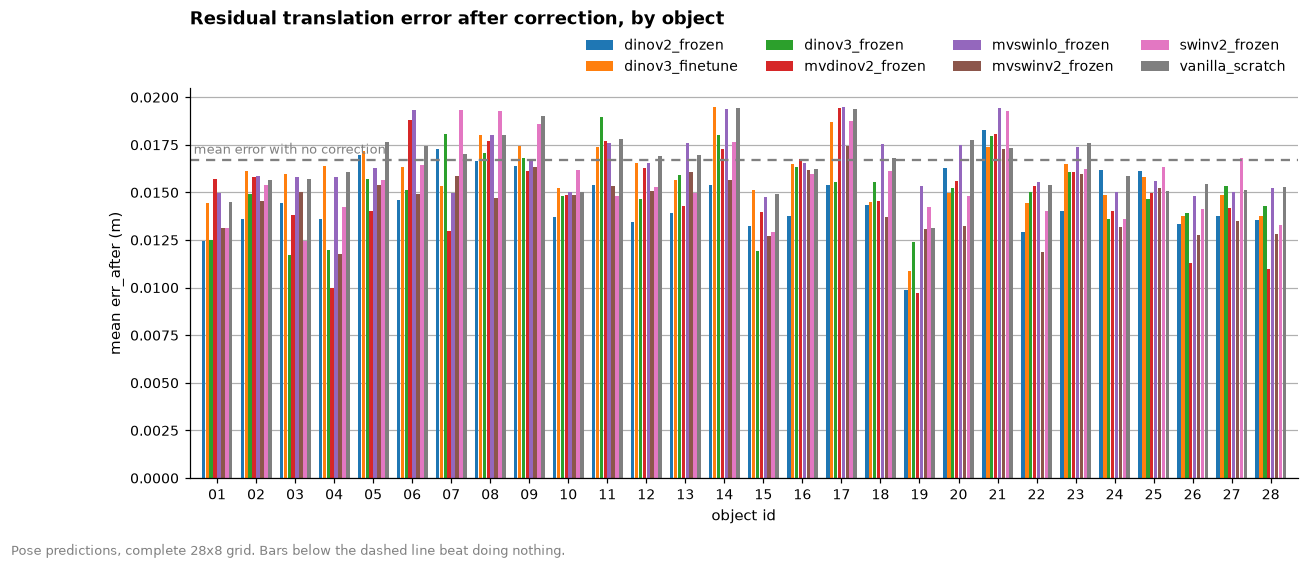

In [36]:
fig, ax = plt.subplots(figsize=(13, 4.6))
objs = pivot_err_after.index.to_numpy()
xs = np.arange(len(objs))
w = 0.8 / len(VARIANTS)
for i, v in enumerate(VARIANTS):
    ax.bar(xs + (i - (len(VARIANTS) - 1) / 2) * w, pivot_err_after[v], width=w * 0.9,
           color=COLOR[v], linewidth=0)
ax.axhline(pose["err_before"].mean(), color="gray", linestyle=(0, (4, 3)), linewidth=1.5)
ax.annotate("mean error with no correction", xy=(-0.6, pose["err_before"].mean()),
            xytext=(0, 4), textcoords="offset points", ha="left", fontsize=8.5, color="gray")
ax.set_xticks(xs, [f"{o:02d}" for o in objs])
ax.set_xlim(-0.7, len(objs) - 0.3)
ax.set_xlabel("object id")
ax.set_ylabel("mean err_after (m)")
ax.set_title("Residual translation error after correction, by object")
ax.grid(axis="x", visible=False)
variant_legend(ax)
caption(fig, f"Pose predictions, complete {len(ALL_OBJS)}x{len(VARIANTS)} grid. "
             "Bars below the dashed line beat doing nothing.")
plt.show()

### 6.2 Overall improvement per model

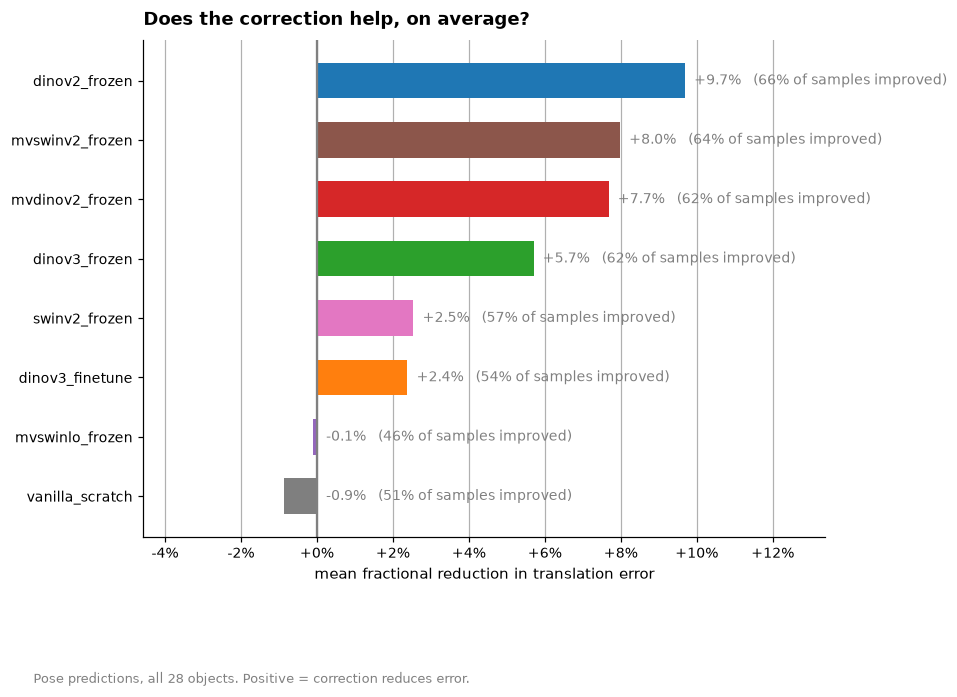

In [37]:
order = pose_summary.sort_values("mean_improvement").index
vals = pose_summary.loc[order, "mean_improvement"]
fig, ax = plt.subplots(figsize=(8, 0.62 * len(order) + 0.9))
ax.barh(np.arange(len(order)), vals, color=[COLOR[v] for v in order], height=0.6, linewidth=0)
ax.axvline(0, color="gray", linewidth=1.5)
for i, (v, val) in enumerate(vals.items()):
    frac = pose_summary.loc[v, "frac_samples_improved"]
    # Always label to the right of zero: a left-side label on a negative bar would
    # land on top of the variant name in the tick column.
    ax.annotate(f"{val:+.1%}   ({frac:.0%} of samples improved)",
                xy=(max(val, 0.0), i), xytext=(6, 0), textcoords="offset points",
                va="center", ha="left", fontsize=9, color="gray")
ax.set_yticks(np.arange(len(order)), order)
ax.set_xlabel("mean fractional reduction in translation error")
ax.set_title("Does the correction help, on average?")
ax.grid(axis="y", visible=False)
ax.margins(x=0.35)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:+.0%}")
caption(fig, f"Pose predictions, all {len(ALL_OBJS)} objects. Positive = correction reduces error.",
        y=-0.10)
plt.show()

### 6.3 Where each model helps and hurts

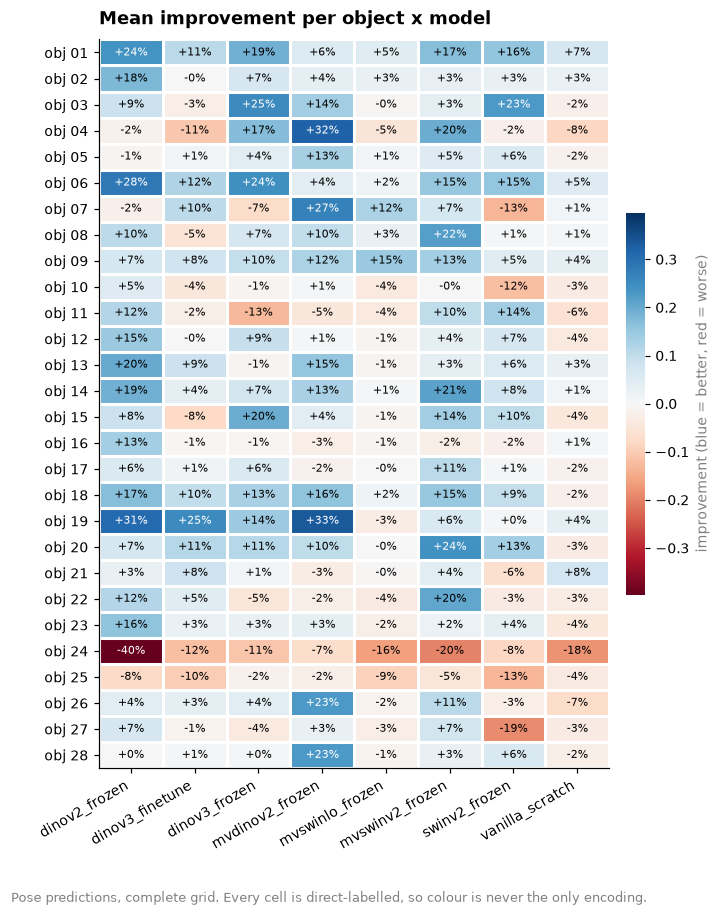

In [38]:
data = pivot_improvement.to_numpy()
lim = np.nanmax(np.abs(data))

fig, ax = plt.subplots(figsize=(6.4, 8.6))
im = ax.imshow(data, cmap="RdBu", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(np.arange(len(VARIANTS)), VARIANTS, rotation=30, ha="right")
ax.set_yticks(np.arange(len(pivot_improvement)), [f"obj {o:02d}" for o in pivot_improvement.index])
for r in range(data.shape[0]):
    for c in range(data.shape[1]):
        val = data[r, c]
        if np.isnan(val):
            continue
        ax.text(c, r, f"{val:+.0%}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(val) > 0.55 * lim else "black")
ax.set_title("Mean improvement per object x model")
ax.grid(visible=False)
ax.set_xticks(np.arange(-0.5, len(VARIANTS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(pivot_improvement), 1), minor=True)
ax.tick_params(which="minor", length=0)
ax.grid(which="minor", color="white", linewidth=2, visible=True)
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cb.set_label("improvement (blue = better, red = worse)", color="gray", fontsize=9)
cb.outline.set_visible(False)
caption(fig, "Pose predictions, complete grid. Every cell is direct-labelled, so colour is never the only encoding.")
plt.show()

### 6.4 Distribution, not just the mean

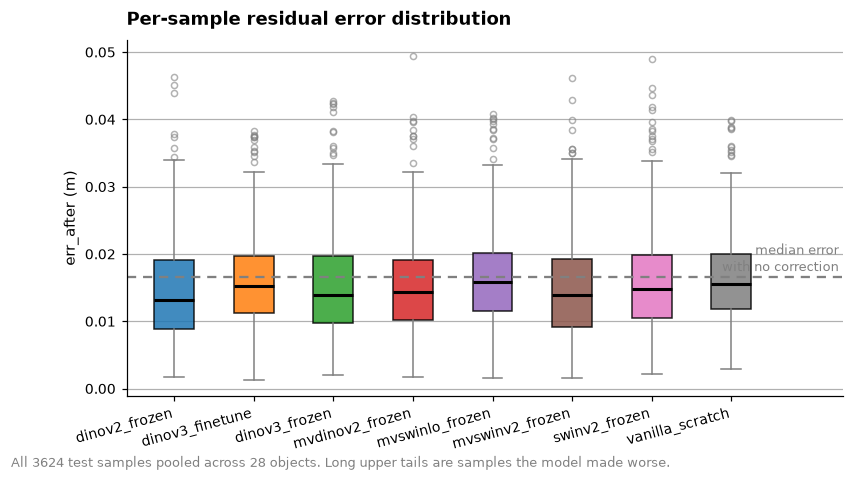

In [28]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
groups = [pose.loc[pose["variant"] == v, "err_after"].to_numpy() for v in VARIANTS]
bp = ax.boxplot(groups, patch_artist=True, widths=0.5, showfliers=True,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color="gray"), capprops=dict(color="gray"),
                flierprops=dict(marker="o", markersize=4, markerfacecolor="none",
                                markeredgecolor="gray", alpha=0.6))
for patch, v in zip(bp["boxes"], VARIANTS):
    patch.set(facecolor=COLOR[v], alpha=0.85)
ax.axhline(pose["err_before"].median(), color="gray", linestyle=(0, (4, 3)), linewidth=1.5)
ax.set_xlim(0.4, len(VARIANTS) + 1.4)  # margin on the right for the reference-line label
ax.annotate("median error\nwith no correction", xy=(len(VARIANTS) + 1.35, pose["err_before"].median()),
            xytext=(0, 4), textcoords="offset points", ha="right", fontsize=8.5, color="gray")
ax.set_xticks(np.arange(1, len(VARIANTS) + 1), VARIANTS, rotation=15, ha="right")
ax.set_ylabel("err_after (m)")
ax.set_title("Per-sample residual error distribution")
ax.grid(axis="x", visible=False)
caption(fig, f"All {len(pose)} test samples pooled across {len(ALL_OBJS)} objects. Long upper tails are samples the model made worse.")
plt.show()

### 6.5 Did the correction actually move each sample the right way?

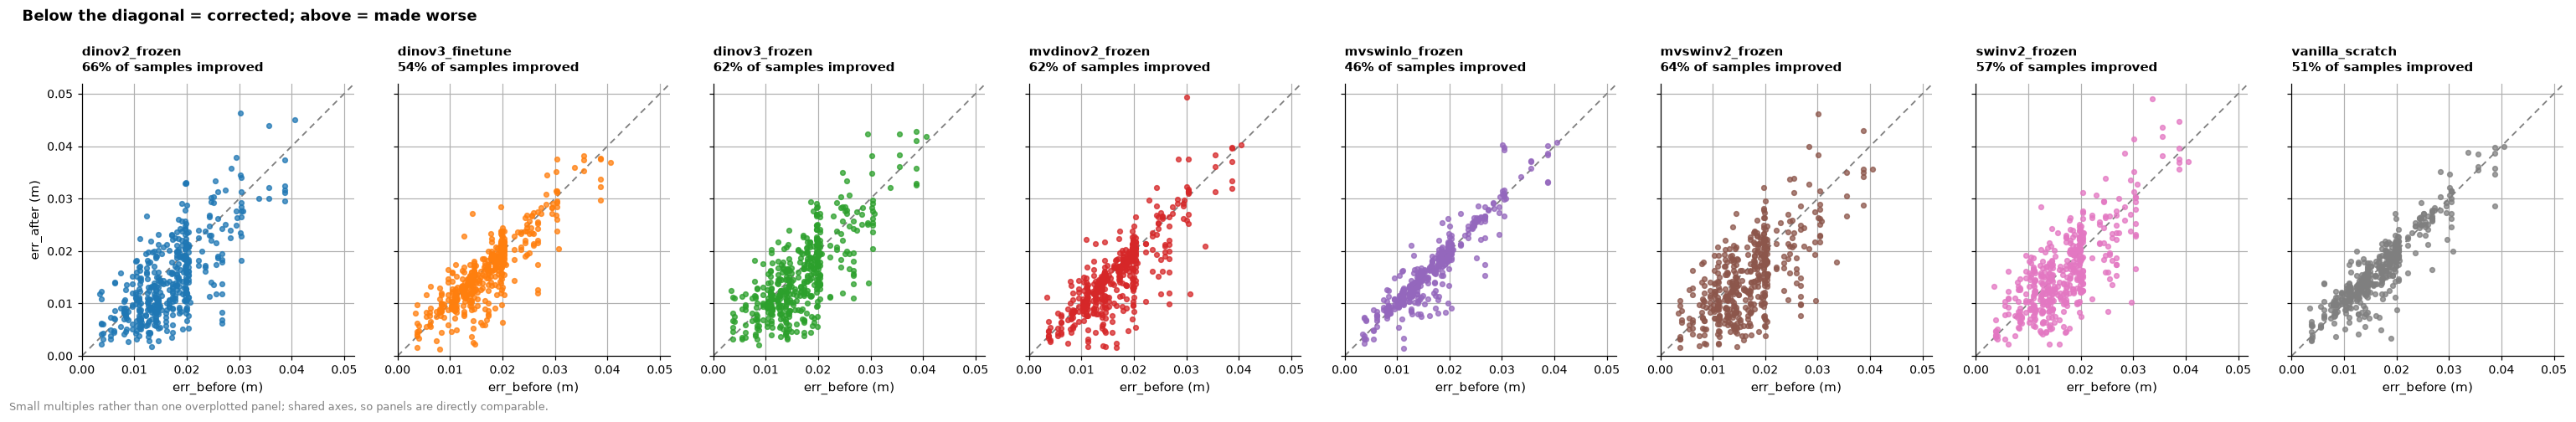

In [29]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(3.5 * len(VARIANTS), 3.8),
                         sharex=True, sharey=True)
hi = max(pose["err_before"].max(), pose["err_after"].max()) * 1.05
for ax, v in zip(axes, VARIANTS):
    sub = pose[pose["variant"] == v]
    worse = (sub["err_after"] > sub["err_before"]).mean()
    ax.plot([0, hi], [0, hi], color="gray", linestyle=(0, (4, 3)), linewidth=1.2, zorder=1)
    ax.scatter(sub["err_before"], sub["err_after"], s=14, color=COLOR[v],
               alpha=0.75, zorder=2)
    ax.set_title(f"{v}\n{1 - worse:.0%} of samples improved", fontsize=10)
    ax.set_xlabel("err_before (m)")
    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_aspect("equal")
axes[0].set_ylabel("err_after (m)")
fig.suptitle("Below the diagonal = corrected; above = made worse", x=0.005, ha="left",
             fontsize=12, fontweight="bold", y=1.06)
plt.tight_layout()
caption(fig, "Small multiples rather than one overplotted panel; shared axes, so panels are directly comparable.", y=-0.06)
plt.show()

### 6.6 Image metrics — fair subset only

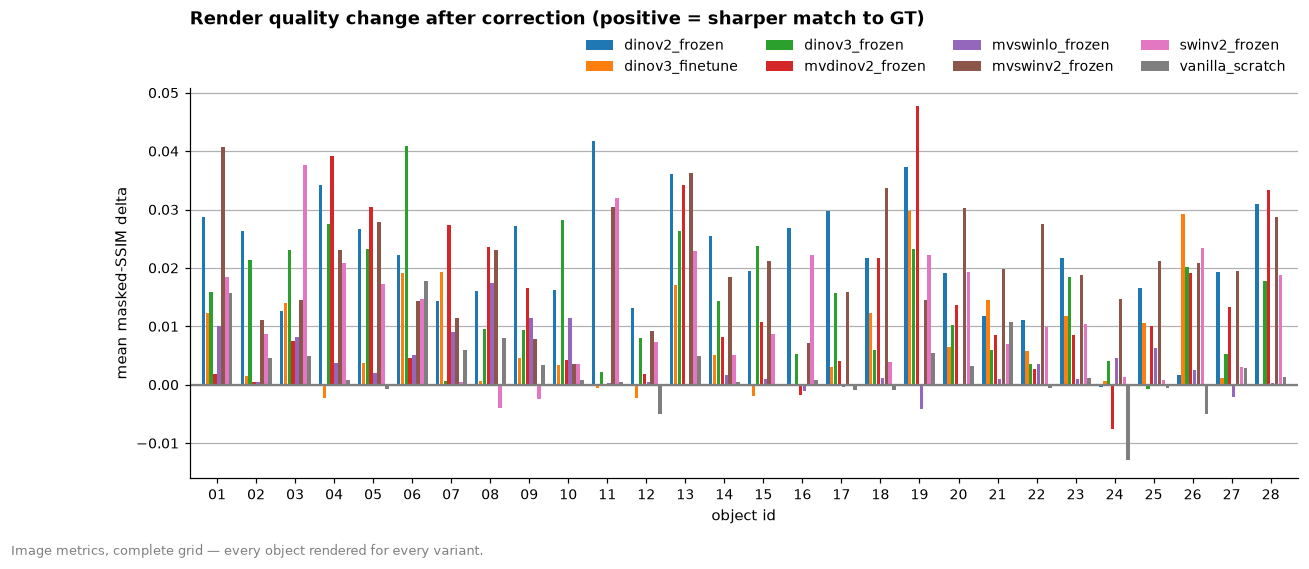

In [30]:
fair_pivot = (img_fair.pivot_table(index="obj_id", columns="variant",
                                   values="ssim_masked_delta", aggfunc="mean")[VARIANTS])
fig, ax = plt.subplots(figsize=(13, 4.6))
xs = np.arange(len(fair_pivot))
w = 0.8 / len(VARIANTS)
for i, v in enumerate(VARIANTS):
    ax.bar(xs + (i - (len(VARIANTS) - 1) / 2) * w, fair_pivot[v], width=w * 0.9,
           color=COLOR[v], linewidth=0)
ax.axhline(0, color="gray", linewidth=1.5)
ax.set_xticks(xs, [f"{o:02d}" for o in fair_pivot.index])
ax.set_xlim(-0.7, len(fair_pivot) - 0.3)
ax.set_xlabel("object id")
ax.set_ylabel("mean masked-SSIM delta")
ax.set_title("Render quality change after correction (positive = sharper match to GT)")
ax.grid(axis="x", visible=False)
variant_legend(ax)
caption(fig, "Image metrics, complete grid — every object rendered for every variant."
             if IMG_COMPLETE else
             f"Restricted to objects {fmt_objs(complete_objs)} — the only ones rendered for every "
             f"variant. The other {img['obj_id'].nunique() - len(complete_objs)} rendered objects are "
             "excluded because comparing them would compare different object sets.")
plt.show()

### 6.7 Do the two metrics agree?

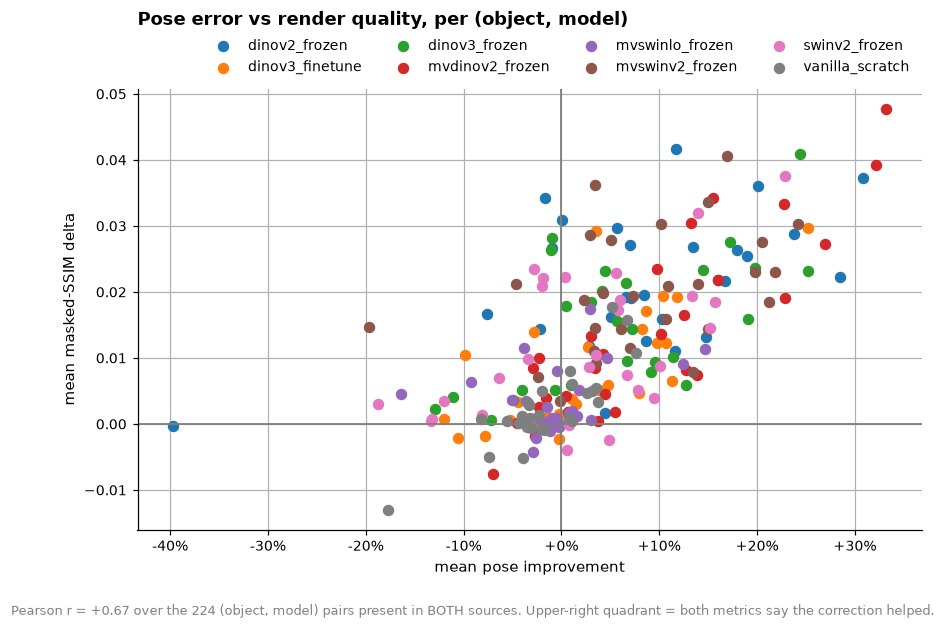

In [31]:
agree = (pose.groupby(["obj_id", "variant"])["improvement"].mean()
             .to_frame()
             .join(img.groupby(["obj_id", "variant"])["ssim_masked_delta"].mean(), how="inner")
             .reset_index())
fig, ax = plt.subplots(figsize=(9.2, 5.2))
for v in VARIANTS:
    sub = agree[agree["variant"] == v]
    ax.scatter(sub["improvement"], sub["ssim_masked_delta"], s=42, color=COLOR[v],
               label=v)
ax.axhline(0, color="gray", linewidth=1.2)
ax.axvline(0, color="gray", linewidth=1.2)
r = agree["improvement"].corr(agree["ssim_masked_delta"])
ax.set_xlabel("mean pose improvement")
ax.set_ylabel("mean masked-SSIM delta")
ax.set_title("Pose error vs render quality, per (object, model)")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:+.0%}")
ax.legend(ncol=4, loc="lower right", bbox_to_anchor=(1.0, 1.005))
lift_title(ax)
caption(fig, f"Pearson r = {r:+.2f} over the {len(agree)} (object, model) pairs present in BOTH sources. "
             "Upper-right quadrant = both metrics say the correction helped.")
plt.show()

## 7 · Takeaway

In [32]:
best_pose = pose_summary.index[0]
best_img = img_summary_fair.index[0]
lines = [
    f"Pose error ({len(ALL_OBJS)} objects x {len(VARIANTS)} variants, {len(pose)} samples)",
    f"  best mean err_after     : {best_pose}  ({pose_summary.loc[best_pose, 'mean_err_after']:.6f} m)",
    f"  best mean improvement   : {pose_summary['mean_improvement'].idxmax()} "
    f"({pose_summary['mean_improvement'].max():+.1%})",
    f"  no-correction baseline  : {pose['err_before'].mean():.6f} m",
    f"  variants beating baseline: "
    f"{sorted(pose_summary.index[pose_summary['mean_err_after'] < pose['err_before'].mean()]) or 'NONE'}",
    "",
    f"Render quality ({'complete grid' if IMG_COMPLETE else 'fair subset'}, "
    f"{fmt_objs(complete_objs)} objects, {len(img_fair)} samples)",
    f"  best mean SSIM delta    : {best_img} ({img_summary_fair.loc[best_img, 'mean_ssim_delta']:+.5f})",
    "",
    "Per-object wins (lowest mean err_after):",
    *[f"  {v:<20} {n:>2} / {len(pivot_err_after)} objects"
      for v, n in winners.value_counts().items()],
]
print("\n".join(lines))

Pose error (28 objects x 8 variants, 3624 samples)
  best mean err_after     : dinov2_frozen  (0.014651 m)
  best mean improvement   : dinov2_frozen (+9.7%)
  no-correction baseline  : 0.016716 m
  variants beating baseline: ['dinov2_frozen', 'dinov3_finetune', 'dinov3_frozen', 'mvdinov2_frozen', 'mvswinlo_frozen', 'mvswinv2_frozen', 'swinv2_frozen', 'vanilla_scratch']

Render quality (complete grid, all 28 objects, 3624 samples)
  best mean SSIM delta    : dinov2_frozen (+0.02151)

Per-object wins (lowest mean err_after):
  dinov2_frozen        10 / 28 objects
  mvdinov2_frozen       7 / 28 objects
  mvswinv2_frozen       7 / 28 objects
  dinov3_frozen         3 / 28 objects
  swinv2_frozen         1 / 28 objects


### What this comparison does *not* cover

- **7 of the 27 possible variants exist.** `MODEL_SPECS` (`models.py`, `models_mv.py`)
  defines nine backbones — `vanilla`, `dinov2`, `dinov3`, `swinv2`, `mvit`, `mvdinov2`,
  `mvdinov3`, `mvswinv2`, `mvswinlo` — and `visualize.py` defines tags `scratch`, `frozen`,
  `finetune`. Run so far: `vanilla_scratch`, `dinov2_frozen`, `dinov3_frozen`,
  `dinov3_finetune`, `swinv2_frozen`, `mvdinov2_frozen`, `mvswinv2_frozen`.
- **Only dinov3 has a frozen-vs-finetune pair**, so "finetuning hurts" is a one-backbone
  observation, not a general one.
- **The multi-view runs are frozen-only**, so single-view vs multi-view is a frozen-only
  comparison (`mvdinov2` vs `dinov2`, `mvswinv2` vs `swinv2`); nothing here says how the
  multi-view heads behave when the backbone is finetuned.
- **One control, one seed.** `vanilla_scratch` is a single from-scratch run at the default
  seed. It bounds what the task gives you for free, but a single run cannot separate
  "pretraining helps" from "this initialisation got lucky".
- **Image-metric coverage depends on `visualize_all.sh` having caught up.** Rendering is a
  separate local step that lags inference, so the image grid can be missing object/variant
  pairs the pose grid has. The coverage matrix in section 3 reports the current state, and
  every image-metric ranking uses the fair subset regardless.
- **Rotation is untested.** Jitter is translation-only, so nothing here says whether any
  backbone can correct orientation.
- **Test splits are small** — 5–27 samples per object/variant, because an object only
  yields samples from the scenes it appears in (`train.py:68-71` holds out 10%). Per-object
  rankings are noisy; the pooled numbers and the win-count tally are the sturdier signals.
- **Masked SSIM is masked** to non-black pixels at threshold 5/255, over 6 tiles per
  sample, so it measures the object region rather than the full frame
  (`visualize.py:139-207`).
- Legacy flat files (`results/metrics.csv`, `results/predictions_dinov2_frozen.csv`) are
  **excluded** — they are obj_000006-only from before the multi-model layout and lack the
  `model`/`tag`/`obj_id` columns.

To refresh: `./pull_data.sh` for new predictions, then `./visualize_all.sh` to fill in the
image-metric gaps, then re-run this notebook top to bottom.
